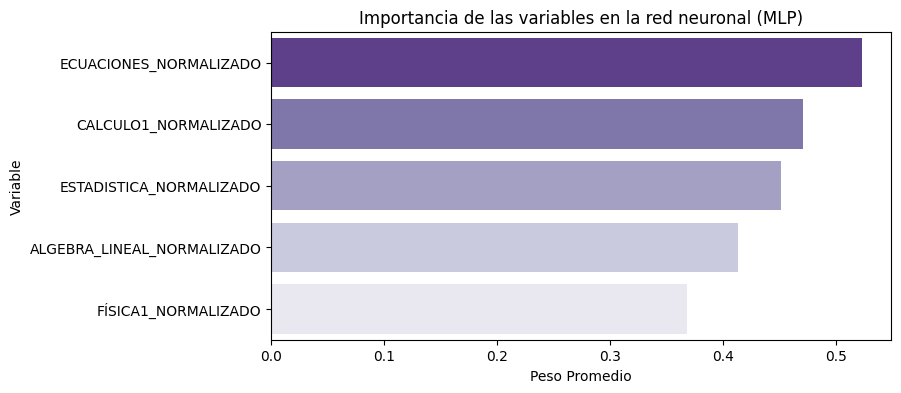


📊 Resultados para Entrenamiento (2010–2018)
Accuracy: 0.907
Precision: 0.919
Recall: 0.79
F1: 0.85
ROC-AUC: 0.946

Matriz de Confusión:
 [[3812  138]
 [ 415 1562]]

               precision    recall  f1-score   support

       False       0.90      0.97      0.93      3950
        True       0.92      0.79      0.85      1977

    accuracy                           0.91      5927
   macro avg       0.91      0.88      0.89      5927
weighted avg       0.91      0.91      0.90      5927



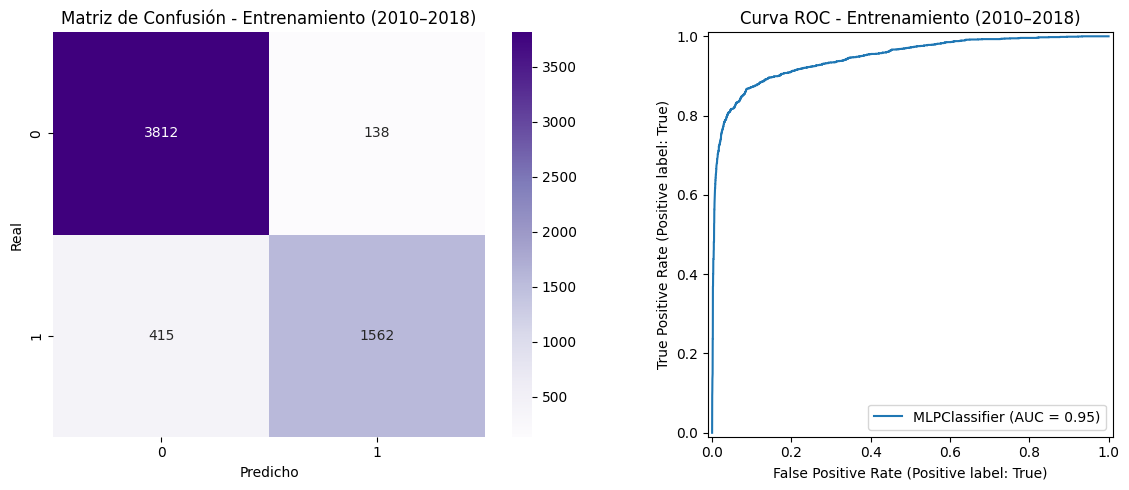


📊 Resultados para Prueba (2019+)
Accuracy: 0.878
Precision: 0.825
Recall: 0.787
F1: 0.806
ROC-AUC: 0.911

Matriz de Confusión:
 [[1449  124]
 [ 158  585]]

               precision    recall  f1-score   support

       False       0.90      0.92      0.91      1573
        True       0.83      0.79      0.81       743

    accuracy                           0.88      2316
   macro avg       0.86      0.85      0.86      2316
weighted avg       0.88      0.88      0.88      2316



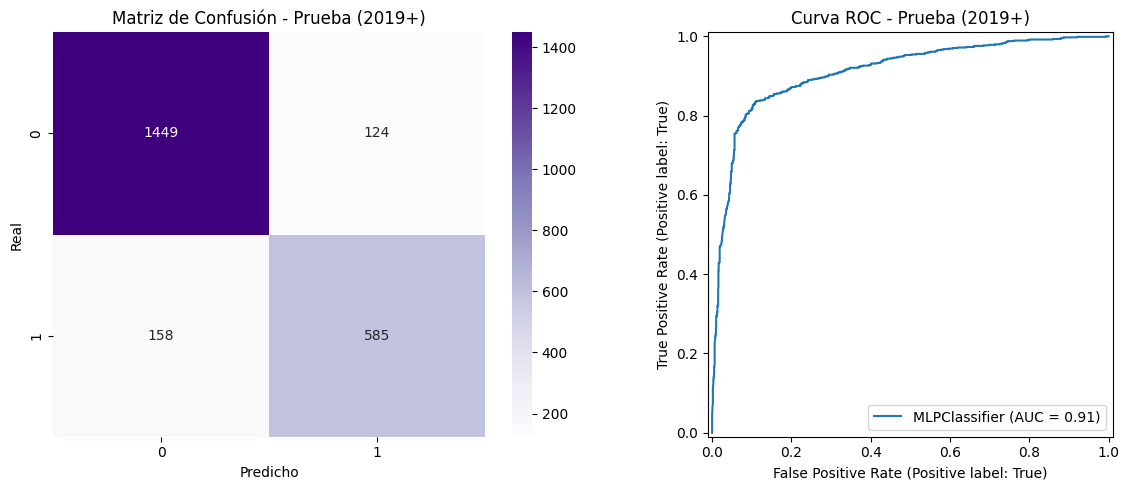

In [2]:
#=============================================
# MODELO RED NEURONAL (MLP)
# ============================================
# 🔹 1. Librerías necesarias
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay
)

# ============================================
# 🔹 2. Cargar datos
# ============================================
df = pd.read_excel("base_para_ml.xlsx")

# Selección de features y variable objetivo
features = [
    'CALCULO1_NORMALIZADO', 'ECUACIONES_NORMALIZADO',
    'ESTADISTICA_NORMALIZADO', 'FÍSICA1_NORMALIZADO',
    'ALGEBRA_LINEAL_NORMALIZADO'
]
target = 'DESERTOR'

df['COHORTE'] = df['COHORTE'].astype(str)
df['AÑO_COHORTE'] = df['COHORTE'].str[:4].astype(int)

train_df = df[df['AÑO_COHORTE'] <= 2018]
test_df = df[(df['AÑO_COHORTE'] >= 2019) & (df['AÑO_COHORTE'] <= 2022)]

train_df = train_df.dropna(subset=features + [target])
test_df = test_df.dropna(subset=features)

X_train = train_df[features]
y_train = train_df[target]

X_test = test_df[features]
y_test = test_df[target] if target in test_df.columns else None

# ============================================
# 🔹 3. Escalamiento de datos
# ============================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ============================================
# 🔹 4. Entrenamiento del modelo MLP
# ============================================
mlp_model = MLPClassifier(
    hidden_layer_sizes=(10, 5),
    activation='relu',
    solver='adam',
    learning_rate_init=0.01,
    max_iter=500,
    random_state=42
)
mlp_model.fit(X_train_scaled, y_train)

# ============================================
# 🔹 5. Importancia de las variables (pesos)
# ============================================
importances = np.mean(np.abs(mlp_model.coefs_[0]), axis=1)
feat_weight = pd.DataFrame({
    'Variable': features,
    'Peso Promedio': importances
}).sort_values(by='Peso Promedio', ascending=False)

# Visualización de pesos
plt.figure(figsize=(8, 4))
sns.barplot(
    data=feat_weight,
    x='Peso Promedio',
    y='Variable',
    hue='Variable',
    palette='Purples_r',
    dodge=False,
    legend=False
)
plt.title("Importancia de las variables en la red neuronal (MLP)")
plt.show()

# ============================================
# 🔹 6. Evaluación del modelo
# ============================================
def evaluar_mlp(modelo, X, y, nombre):
    y_pred = modelo.predict(X)
    y_proba = modelo.predict_proba(X)[:, 1]

    print(f"\n📊 Resultados para {nombre}")
    print("Accuracy:", round(accuracy_score(y, y_pred), 3))
    print("Precision:", round(precision_score(y, y_pred), 3))
    print("Recall:", round(recall_score(y, y_pred), 3))
    print("F1:", round(f1_score(y, y_pred), 3))
    print("ROC-AUC:", round(roc_auc_score(y, y_proba), 3))
    print("\nMatriz de Confusión:\n", confusion_matrix(y, y_pred))
    print("\n", classification_report(y, y_pred))

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    sns.heatmap(confusion_matrix(y, y_pred), annot=True, fmt='d', cmap='Purples', ax=axes[0])
    axes[0].set_title(f'Matriz de Confusión - {nombre}')
    axes[0].set_xlabel("Predicho")
    axes[0].set_ylabel("Real")

    RocCurveDisplay.from_estimator(modelo, X, y, ax=axes[1])
    axes[1].set_title(f'Curva ROC - {nombre}')

    plt.tight_layout()
    plt.show()

# Evaluar en entrenamiento
evaluar_mlp(mlp_model, X_train_scaled, y_train, "Entrenamiento (2010–2018)")

# Evaluar o predecir en prueba
if y_test is not None and len(y_test) > 0:
    evaluar_mlp(mlp_model, X_test_scaled, y_test, "Prueba (2019+)")
else:
    print("\n⚠️ Cohortes 2019+ no tienen 'DESERTOR'; generando solo predicciones.")
    test_df['PROB_DESERCIÓN'] = mlp_model.predict_proba(X_test_scaled)[:, 1]


✅ Evaluando modelo MLP...


📊 Resultados para Entrenamiento (2010–2018)
Accuracy: 0.907
Precision: 0.919
Recall: 0.790
F1: 0.850
ROC-AUC: 0.946

              precision    recall  f1-score   support

       False      0.902     0.965     0.932      3950
        True      0.919     0.790     0.850      1977

    accuracy                          0.907      5927
   macro avg      0.910     0.878     0.891      5927
weighted avg      0.907     0.907     0.905      5927



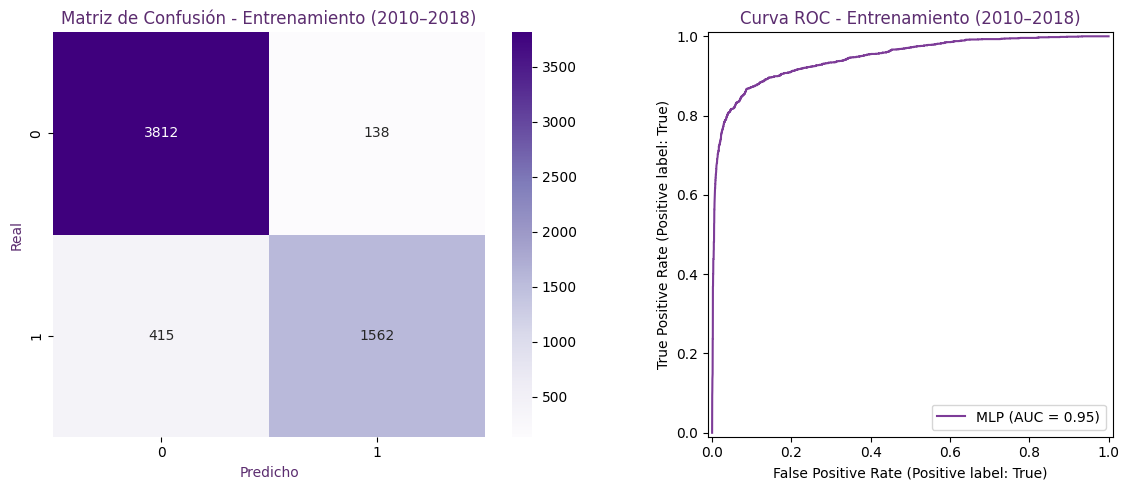


📊 Resultados para Prueba (2019–2022)
Accuracy: 0.878
Precision: 0.825
Recall: 0.787
F1: 0.806
ROC-AUC: 0.911

              precision    recall  f1-score   support

       False      0.902     0.921     0.911      1573
        True      0.825     0.787     0.806       743

    accuracy                          0.878      2316
   macro avg      0.863     0.854     0.859      2316
weighted avg      0.877     0.878     0.877      2316



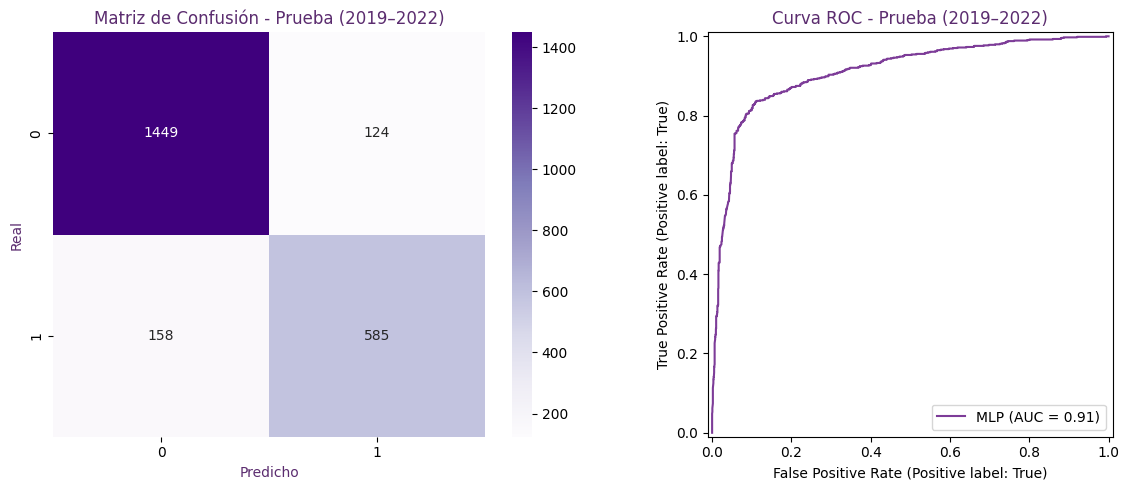


📋 Resumen de métricas del modelo MLP:


,Accuracy,Precision,Recall,F1,ROC-AUC
Entrenamiento,0.906698,0.918824,0.790086,0.849606,0.946291
Prueba,0.878238,0.825106,0.787349,0.805785,0.911303


🔍 Iniciando análisis agregado de predicciones (MLP)...

Total estudiantes (2019+): 2316
Predichos desertores: 709 (30.61%)
Predichos no desertores: 1607 (69.39%)


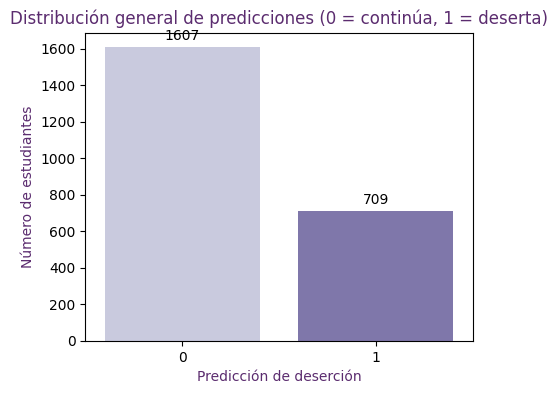


📈 Porcentaje proyectado de desertores por cohorte:
  COHORTE  Porcentaje_desertores
0  2019-1              29.498525
1  2019-2              30.726257
2  2020-1              23.677582
3  2020-2              31.764706
4  2021-1              30.102041


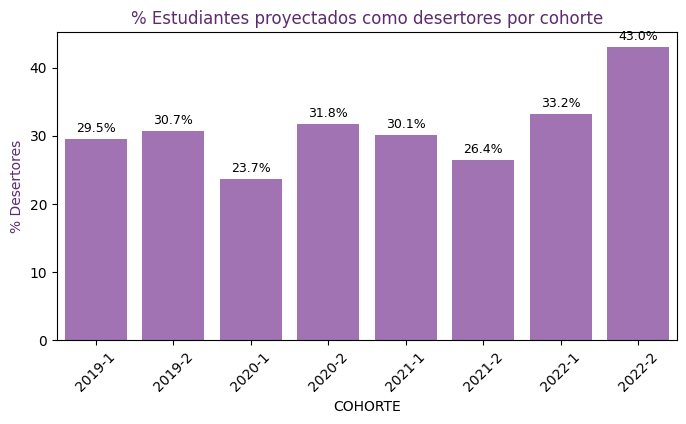

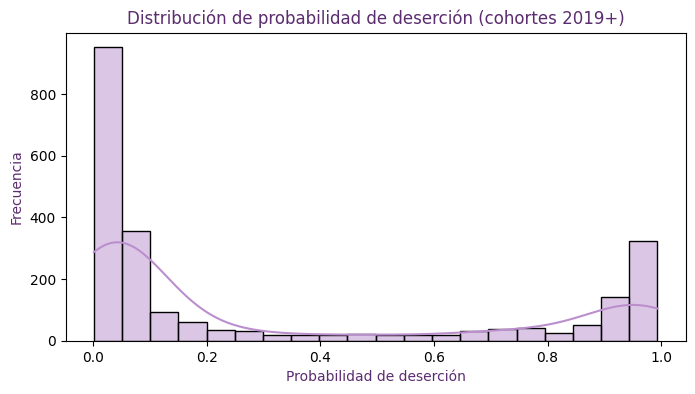

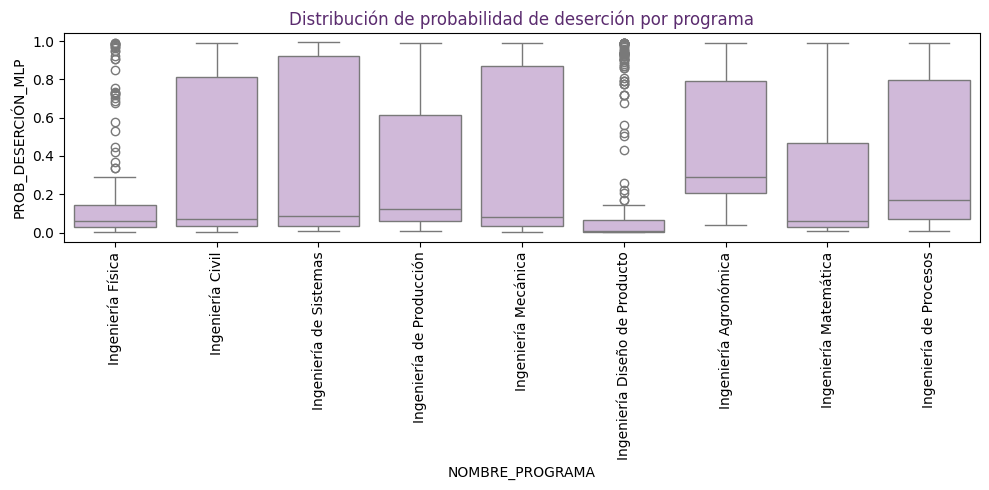


🏫 Top 10 programas con mayor probabilidad media de deserción:
NOMBRE_PROGRAMA
Ingeniería Agronómica            0.471166
Ingeniería de Sistemas           0.389957
Ingeniería de Procesos           0.379658
Ingeniería Mecánica              0.348875
Ingeniería de Producción         0.333071
Ingeniería Civil                 0.315729
Ingeniería Matemática            0.251178
Ingeniería Física                0.202676
Ingeniería Diseño de Producto    0.181203
Name: PROB_DESERCIÓN_MLP, dtype: float64


/tmp/ipython-input-3807610374.py:152: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=top_programas.values, y=top_programas.index, palette='Purples', legend=False)


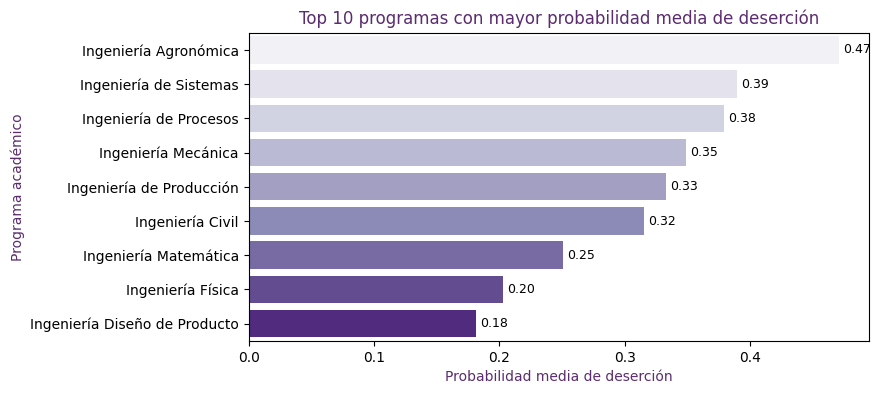

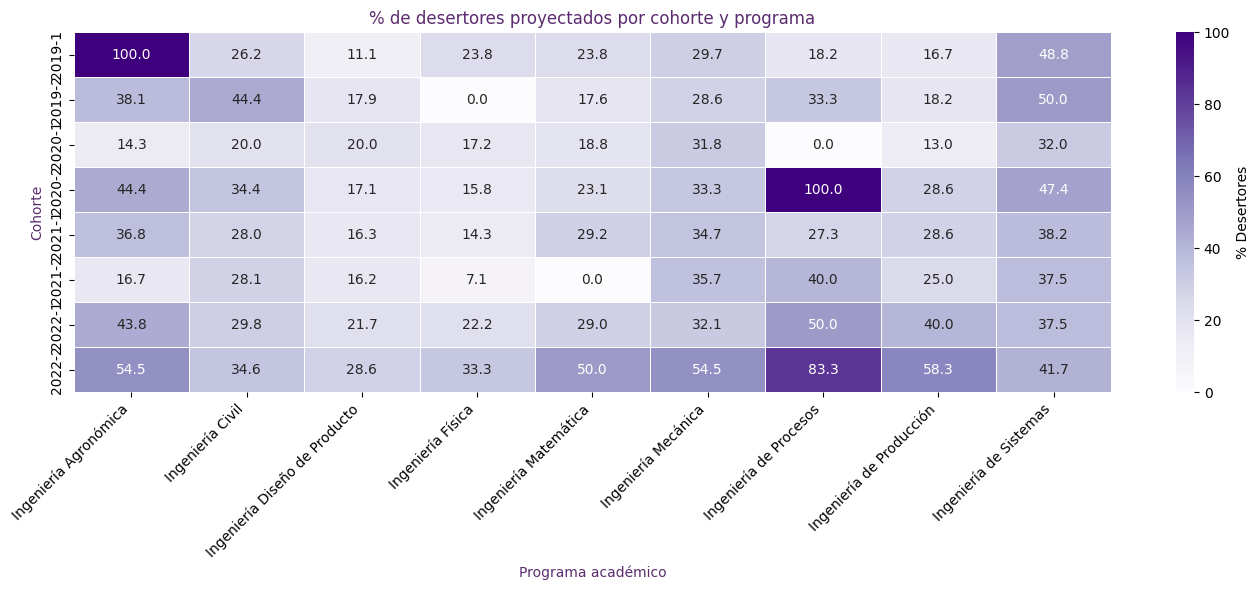


✅ Análisis completo de predicciones (MLP) finalizado correctamente.


In [7]:
# ============================================
# 🔹 10. Evaluación del modelo MLP (con gráficas moradas)
# ============================================

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay
)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

def evaluar_mlp(modelo, X, y, nombre):
    """Evalúa el modelo MLP e imprime métricas y gráficos en color morado."""
    y_pred = modelo.predict(X)
    y_proba = modelo.predict_proba(X)[:, 1]

    acc = accuracy_score(y, y_pred)
    prec = precision_score(y, y_pred)
    rec = recall_score(y, y_pred)
    f1 = f1_score(y, y_pred)
    roc = roc_auc_score(y, y_proba)

    print(f"\n📊 Resultados para {nombre}")
    print(f"Accuracy: {acc:.3f}")
    print(f"Precision: {prec:.3f}")
    print(f"Recall: {rec:.3f}")
    print(f"F1: {f1:.3f}")
    print(f"ROC-AUC: {roc:.3f}\n")
    print(classification_report(y, y_pred, digits=3))

    # === Gráficas de evaluación (en morado) ===
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Matriz de confusión
    sns.heatmap(confusion_matrix(y, y_pred), annot=True, fmt='d',
                cmap='Purples', ax=axes[0])  # 💜 color morado
    axes[0].set_title(f'Matriz de Confusión - {nombre}', color='#5B2C6F')
    axes[0].set_xlabel("Predicho", color='#5B2C6F')
    axes[0].set_ylabel("Real", color='#5B2C6F')

    # Curva ROC
    RocCurveDisplay.from_estimator(modelo, X, y, ax=axes[1], name='MLP',
                                   color='#7D3C98')  # 💜 tono morado oscuro
    axes[1].set_title(f'Curva ROC - {nombre}', color='#5B2C6F')

    plt.tight_layout()
    plt.show()

    return {"Accuracy": acc, "Precision": prec, "Recall": rec, "F1": f1, "ROC-AUC": roc}


# === Evaluación en entrenamiento y prueba ===
print("✅ Evaluando modelo MLP...\n")
resultados_train = evaluar_mlp(mlp_model, X_train_scaled, y_train, "Entrenamiento (2010–2018)")
resultados_test = evaluar_mlp(mlp_model, X_test_scaled, y_test, "Prueba (2019–2022)")

# === Resumen de métricas ===
tabla_resultados = pd.DataFrame([resultados_train, resultados_test],
                                index=["Entrenamiento", "Prueba"])
print("\n📋 Resumen de métricas del modelo MLP:")
display(tabla_resultados)


# ============================================
# 🔹 11. Análisis agregado de predicciones – Modelo MLP
# ============================================

print("🔍 Iniciando análisis agregado de predicciones (MLP)...\n")

# 1️⃣ Probabilidades y predicciones binarias
if 'PROB_DESERCIÓN_MLP' not in test_df.columns:
    test_df['PROB_DESERCIÓN_MLP'] = mlp_model.predict_proba(X_test_scaled)[:, 1]
test_df['PRED_DESERTOR_MLP'] = np.where(test_df['PROB_DESERCIÓN_MLP'] >= 0.5, 1, 0)

# 2️⃣ Distribución general de predicciones
total = len(test_df)
desertores = test_df['PRED_DESERTOR_MLP'].sum()
no_desertores = total - desertores
porc_desertores = round(desertores / total * 100, 2)

print(f"Total estudiantes (2019+): {total}")
print(f"Predichos desertores: {desertores} ({porc_desertores}%)")
print(f"Predichos no desertores: {no_desertores} ({round(100 - porc_desertores, 2)}%)")

plt.figure(figsize=(5, 4))
ax = sns.countplot(data=test_df, x='PRED_DESERTOR_MLP', hue='PRED_DESERTOR_MLP',
                   palette='Purples', legend=False)
plt.title('Distribución general de predicciones (0 = continúa, 1 = deserta)', color='#5B2C6F')
plt.xlabel('Predicción de deserción', color='#5B2C6F')
plt.ylabel('Número de estudiantes', color='#5B2C6F')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10, color='black', xytext=(0, 3),
                textcoords='offset points')
plt.show()

# 3️⃣ Desertores proyectados por cohorte
if 'COHORTE' in test_df.columns:
    cohorte_summary = (
        test_df.groupby('COHORTE')['PRED_DESERTOR_MLP']
        .mean()
        .reset_index(name='Porcentaje_desertores')
    )
    cohorte_summary['Porcentaje_desertores'] *= 100
    print("\n📈 Porcentaje proyectado de desertores por cohorte:")
    print(cohorte_summary.head())

    plt.figure(figsize=(8, 4))
    ax = sns.barplot(data=cohorte_summary, x='COHORTE', y='Porcentaje_desertores',
                     color='#A569BD', legend=False)
    plt.title('% Estudiantes proyectados como desertores por cohorte', color='#5B2C6F')
    plt.xticks(rotation=45)
    plt.ylabel('% Desertores', color='#5B2C6F')
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.1f}%',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=9, color='black', xytext=(0, 3),
                    textcoords='offset points')
    plt.show()

# 4️⃣ Distribución de probabilidad de deserción
plt.figure(figsize=(8, 4))
sns.histplot(test_df['PROB_DESERCIÓN_MLP'], bins=20, kde=True, color='#BB8FCE')
plt.title('Distribución de probabilidad de deserción (cohortes 2019+)', color='#5B2C6F')
plt.xlabel('Probabilidad de deserción', color='#5B2C6F')
plt.ylabel('Frecuencia', color='#5B2C6F')
plt.show()

# 5️⃣ Distribución por programa y top 10
if 'NOMBRE_PROGRAMA' in test_df.columns:
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=test_df, x='NOMBRE_PROGRAMA', y='PROB_DESERCIÓN_MLP', color='#D2B4DE')
    plt.title('Distribución de probabilidad de deserción por programa', color='#5B2C6F')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

    top_programas = (
        test_df.groupby('NOMBRE_PROGRAMA')['PROB_DESERCIÓN_MLP']
        .mean()
        .sort_values(ascending=False)
        .head(10)
    )

    print("\n🏫 Top 10 programas con mayor probabilidad media de deserción:")
    print(top_programas)

    plt.figure(figsize=(8, 4))
    ax = sns.barplot(x=top_programas.values, y=top_programas.index, palette='Purples', legend=False)
    plt.title('Top 10 programas con mayor probabilidad media de deserción', color='#5B2C6F')
    plt.xlabel('Probabilidad media de deserción', color='#5B2C6F')
    plt.ylabel('Programa académico', color='#5B2C6F')
    for p in ax.patches:
        width = p.get_width()
        ax.annotate(f'{width:.2f}',
                    (width, p.get_y() + p.get_height() / 2),
                    ha='left', va='center', fontsize=9, color='black', xytext=(3, 0),
                    textcoords='offset points')
    plt.show()

# 6️⃣ Mapa de calor cohorte–programa
if {'COHORTE', 'NOMBRE_PROGRAMA'}.issubset(test_df.columns):
    pivot = (
        test_df.groupby(['COHORTE', 'NOMBRE_PROGRAMA'])['PRED_DESERTOR_MLP']
        .mean()
        .unstack(fill_value=0) * 100
    )

    plt.figure(figsize=(14, 6))
    sns.heatmap(pivot, cmap='Purples', annot=True, fmt=".1f", linewidths=0.5,
                cbar_kws={'label': '% Desertores'})
    plt.title('% de desertores proyectados por cohorte y programa', color='#5B2C6F')
    plt.xlabel('Programa académico', color='#5B2C6F')
    plt.ylabel('Cohorte', color='#5B2C6F')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

print("\n✅ Análisis completo de predicciones (MLP) finalizado correctamente.")
